<table>
<tr><td><img style="height: 150px;" src="images/geo_hydro1.jpg"></td>
<td bgcolor="#FFFFFF">
    <p style="font-size: xx-large; font-weight: 900; line-height: 100%">pySTALAGMITE</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);"><b style=color:red;>STALAGMITE</b> modelling</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Georg Kaufmann</p>
    </td>
<td><img style="height: 150px;" src="images/pySTALAGMITE.png"></td>
</tr>
</table>

----
# `pySTALAGMITE`

pySTALAGMITE, a program package prediction the shape of a stalagmite from pre-defined climate conditions.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import sys

import libCHEM,libSTALAGMITE

----
# Run `pySTALAGMITE`

Now we have assembed and discussed all relevant functions.

We group the functions in a wrapper function, `pySTALAGMITE_GEOM()`.
Several options are passed:

- `infile1`: name of parameter file (default: STALAGMITE_parameter.in)
- `infile2`: name of timeline file (default: STALAGMITE_timeline.in)
- `path`: path to parameter file (default: work/)
- `mix`: mixing between open(mix=1) and closed (mix=0) system
- `climate`: flag for cimate driver (see below)
- `plot': flag for plotting

In [4]:
def pySTALAGMITE_GEOM(infile1='STALAGMITE_parameter.in',infile2='STALAGMITE_timeline.in',path='work/',mix=0.5,climate='simple',plot=False):
    #---------------------
    # initial setup
    #---------------------
    Vdrop=0.1e-6;year2sec = 365.25*24*60*60
    # read parameter
    sidex,nx,init_height,timeStep,timeWrite,TSoilmin,TSoilmax,PSoilmin,PSoilmax, \
            PAtmmin,PAtmmax,TCavemin,TCavemax,PCavemin,PCavemax,DCavemin,DCavemax = \
            libSTALAGMITE.readParameter2D(infile=infile1,path=path,control=True)
    # read timeline
    timeStart,timeEnd,rawTimeline = libSTALAGMITE.readTimeline2D(infile=infile2,path=path,control=True)
    # create grid
    x,y,dx = libSTALAGMITE.createGrid2D(sidex,nx,init_height=init_height,plot=False)
    # define stack for geometry
    nstack = 50
    stal   = np.zeros(nx*2*nstack).reshape(nx,2,nstack)
    tSaved = np.zeros(nstack)
    stal[:,0,0] = x
    stal[:,1,0] = y
    tSaved[0]   = timeStart
    #---------------------
    # time loop
    #---------------------
    iSaved = 0
    itime  = 0
    time   = timeStart+ timeStep
    while (time <= timeEnd):
        # climate parameter
        TSoil,PSoil,TCave,PCave,DCave = libSTALAGMITE.setClimate2D(time,timeStart,timeEnd,
               TSoilmin,TSoilmax,
               PSoilmin,PSoilmax,
               TCavemin,TCavemax,
               PCavemin,PCavemax,
               DCavemin,DCavemax,rawTimeline=rawTimeline,climate=climate)
        Q     = Vdrop / DCave
        # drop chemistry
        CEQopen   = libCHEM.CEQ_limestone_open(TSoil,PSoil/1e6)
        CEQclosed = libCHEM.CEQ_limestone_closed(TSoil,PSoil/1e6)
        Cin       = mix*CEQopen + (1-mix)*CEQclosed
        CEQcave   = 1.12 * libCHEM.CEQ_limestone_open(TCave,PCave/1e6)
        # growth rate and equilibrium radius
        W0 = libSTALAGMITE.growthRate2D(Cin,CEQcave,DCave,TSoil)
        R0 = libSTALAGMITE.equiRadius2D(Cin,CEQcave,DCave,TSoil)
        # refine grid    
        if (x[1] > 1.5*dx):
            x,y = libSTALAGMITE.refineGrid2D(x,y)
        # loop along surface
        growth = np.zeros(len(x))
        angle  = np.zeros(len(x))
        arc       = 0.
        growth[0] = W0*timeStep*year2sec
        angle[0]  = 0.
        for i in range(1,len(x)):
            dl        = np.sqrt((x[i-1]-x[i])**2 + (y[i-1]-y[i])**2)
            arc       = arc + dl
            angle[i]  = np.arcsin((y[i-1]-y[i])/dl)
            growth[i] = W0*timeStep*year2sec*np.exp(-arc/R0)
        # update shape
        x[0]      = x[0]
        y[0]      = y[0] + growth[0]
        for i in range(1,len(x)):
            x[i] = x[i] + growth[i]*np.sin(angle[i])
            y[i] = y[i] + growth[i]*np.cos(angle[i])
        # save time step
        if (time % timeWrite == 0):
            iSaved = iSaved + 1
            if (iSaved > stal.shape[2]-1):
                print('iSaved too large')
                sys.exit()
            print('%30s %10i %10.2f %10.2f' % ('Time step, time [a], TSoil [C]:',iSaved,time,TSoil))
            stal[:,0,iSaved] = x
            stal[:,1,iSaved] = y
            tSaved[iSaved] = time
        # update time step
        time += timeStep
        itime += 1
    #---------------------
    # plot shape
    #---------------------
    if (plot):
        libSTALAGMITE.plotStalagmite2D(stal,iSaved,tSaved,sidex)
    return sidex,stal,iSaved,tSaved

----
## Run model `simple1` (constant conditions)

In [5]:
sidex,stal,iSaved,tSaved = pySTALAGMITE_GEOM(path='div/run_simple1/',climate='simple')

== STALAGMITE ==
                         path:     div/run_simple1/
                 sidex [m],nx:       0.40        801
              init_height [m]:       0.01
       timestep,timewrite [a]:      10.00      1000.00
        TSoilmin,TSoilmax [C]:      10.00        10.00
      PSoilmin,PSoilmax [ppm]:   30000.00     30000.00
        PAtmmin,PAtmmax [ppm]:     400.00       400.00
        TCavemin,TCavemax [C]:      10.00        10.00
      PCavemin,PCavemax [ppm]:     400.00       400.00
  dropCavemin,dropCavemax [s]:     100.00       100.00
        timeStart,timeEnd [a]:  -10000.00         0.00
Time step, time [a], TSoil [C]:          1   -9000.00      10.00
Time step, time [a], TSoil [C]:          2   -8000.00      10.00
Time step, time [a], TSoil [C]:          3   -7000.00      10.00
Time step, time [a], TSoil [C]:          4   -6000.00      10.00
Time step, time [a], TSoil [C]:          5   -5000.00      10.00
Time step, time [a], TSoil [C]:          6   -4000.00      10.00
Time s

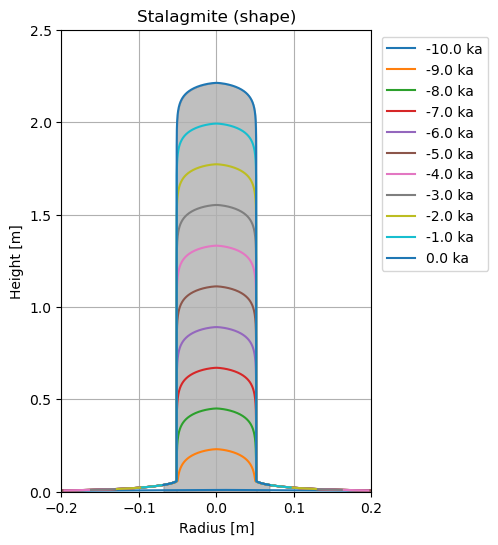

In [6]:
libSTALAGMITE.plotStalagmite2D(stal,iSaved,tSaved,sidex)

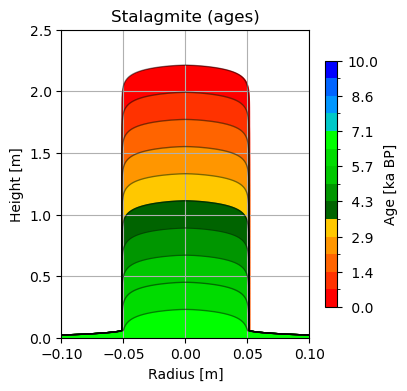

In [7]:
libSTALAGMITE.plotStalagmiteAges2D(stal,iSaved,tSaved,sidex)

----
## Run model `simple2` (increase in soil temperature)

== STALAGMITE ==
                         path:     div/run_simple2/
                 sidex [m],nx:       0.40        801
              init_height [m]:       0.01
       timestep,timewrite [a]:      10.00      1000.00
        TSoilmin,TSoilmax [C]:       0.00        10.00
      PSoilmin,PSoilmax [ppm]:   30000.00     30000.00
        PAtmmin,PAtmmax [ppm]:     400.00       400.00
        TCavemin,TCavemax [C]:      10.00        10.00
      PCavemin,PCavemax [ppm]:     400.00       400.00
  dropCavemin,dropCavemax [s]:     100.00       100.00
        timeStart,timeEnd [a]:  -10000.00         0.00
Time step, time [a], TSoil [C]:          1   -9000.00       1.00
Time step, time [a], TSoil [C]:          2   -8000.00       2.00
Time step, time [a], TSoil [C]:          3   -7000.00       3.00
Time step, time [a], TSoil [C]:          4   -6000.00       4.00
Time step, time [a], TSoil [C]:          5   -5000.00       5.00
Time step, time [a], TSoil [C]:          6   -4000.00       6.00
Time s

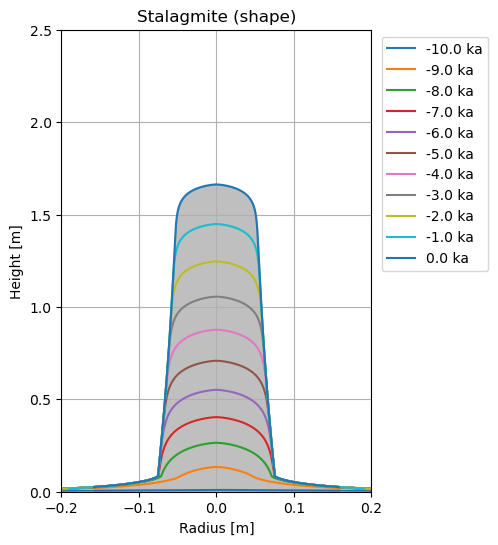

In [8]:
sidex,stal,iSaved,tSaved = pySTALAGMITE_GEOM(path='div/run_simple2/',climate='simple')
libSTALAGMITE.plotStalagmite2D(stal,iSaved,tSaved,sidex)

----
## Run model `simple3` (increase in soil CO$_2$ concentration)

== STALAGMITE ==
                         path:     div/run_simple3/
                 sidex [m],nx:       0.40        801
              init_height [m]:       0.01
       timestep,timewrite [a]:      10.00      1000.00
        TSoilmin,TSoilmax [C]:      10.00        10.00
      PSoilmin,PSoilmax [ppm]:     400.00     30000.00
        PAtmmin,PAtmmax [ppm]:     400.00       400.00
        TCavemin,TCavemax [C]:      10.00        10.00
      PCavemin,PCavemax [ppm]:     400.00       400.00
  dropCavemin,dropCavemax [s]:     100.00       100.00
        timeStart,timeEnd [a]:  -10000.00         0.00
Time step, time [a], TSoil [C]:          1   -9000.00      10.00


/var/folders/g1/lkn34rdd3158l1w_kz2l0dt80000gn/T/ipykernel_7877/1288124663.py:57: RuntimeWarning: divide by zero encountered in scalar divide
  growth[i] = W0*timeStep*year2sec*np.exp(-arc/R0)


Time step, time [a], TSoil [C]:          2   -8000.00      10.00
Time step, time [a], TSoil [C]:          3   -7000.00      10.00
Time step, time [a], TSoil [C]:          4   -6000.00      10.00
Time step, time [a], TSoil [C]:          5   -5000.00      10.00
Time step, time [a], TSoil [C]:          6   -4000.00      10.00
Time step, time [a], TSoil [C]:          7   -3000.00      10.00
Time step, time [a], TSoil [C]:          8   -2000.00      10.00
Time step, time [a], TSoil [C]:          9   -1000.00      10.00
Time step, time [a], TSoil [C]:         10       0.00      10.00


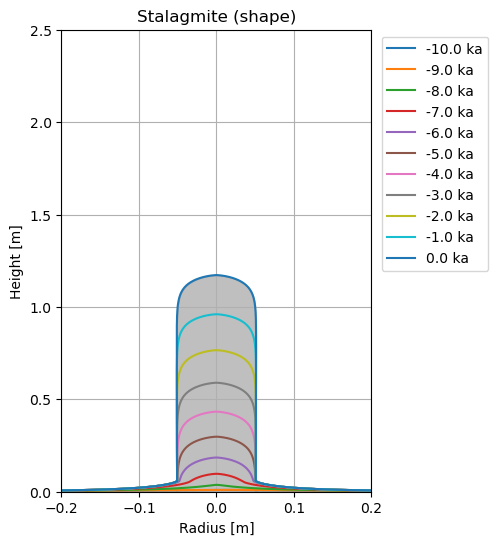

In [9]:
sidex,stal,iSaved,tSaved = pySTALAGMITE_GEOM(path='div/run_simple3/',climate='simple')
libSTALAGMITE.plotStalagmite2D(stal,iSaved,tSaved,sidex)

----
## Run model `simple4` (decrease in drip interval, wetter)

== STALAGMITE ==
                         path:     div/run_simple4/
                 sidex [m],nx:       0.40        801
              init_height [m]:       0.01
       timestep,timewrite [a]:      10.00      1000.00
        TSoilmin,TSoilmax [C]:      10.00        10.00
      PSoilmin,PSoilmax [ppm]:   30000.00     30000.00
        PAtmmin,PAtmmax [ppm]:     400.00       400.00
        TCavemin,TCavemax [C]:      10.00        10.00
      PCavemin,PCavemax [ppm]:     400.00       400.00
  dropCavemin,dropCavemax [s]:    1000.00       100.00
        timeStart,timeEnd [a]:  -10000.00         0.00
Time step, time [a], TSoil [C]:          1   -9000.00      10.00
Time step, time [a], TSoil [C]:          2   -8000.00      10.00
Time step, time [a], TSoil [C]:          3   -7000.00      10.00
Time step, time [a], TSoil [C]:          4   -6000.00      10.00
Time step, time [a], TSoil [C]:          5   -5000.00      10.00
Time step, time [a], TSoil [C]:          6   -4000.00      10.00
Time s

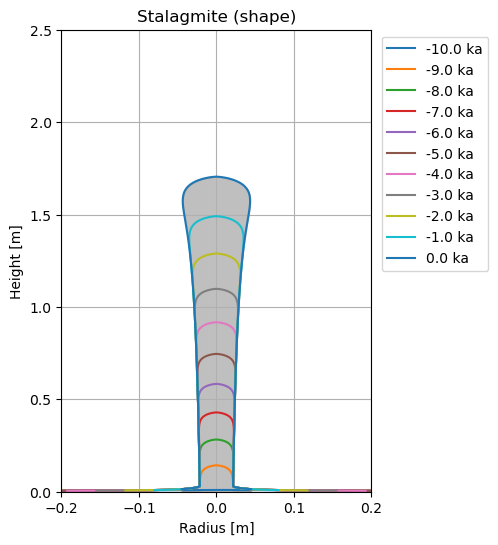

In [10]:
sidex,stal,iSaved,tSaved = pySTALAGMITE_GEOM(path='div/run_simple4/',climate='simple')
libSTALAGMITE.plotStalagmite2D(stal,iSaved,tSaved,sidex)

----